# E-field energy density: vacuum / C8H8 / Si

Toy stack at 250 eV with **lab-frame** coordinates (beam from the top):

| Region                                      | $z$ (nm)          |
| ------------------------------------------- | ----------------- |
| **Vacuum** (incident semi-infinite)         | $z > 200$         |
| **C8H8** film ($\rho = 1\,\mathrm{g/cm^3}$) | $0 \le z \le 200$ |
| **Si** substrate                            | $z < 0$           |

The plane $z = 0$ is the Si/C8H8 interface; $z = 200\,\mathrm{nm}$ is the C8H8/vacuum interface. Interfaces are smooth ($\sigma = 0$); s-polarized plane wave from vacuum ($+z$).

Reflectivity uses the usual `tjf4x4` ordering (vacuum fronting); field maps translate lab $z$ to that frame via $z_\mathrm{tmm} = d - z$.

**Note on what you see:** time-averaged $|E_y|^2$ for a uniform plane wave is **constant in $x$** (because $|e^{ik_x x}|^2 = 1$). The incident wave appears as a **standing-wave pattern in $z$** in vacuum (incident + reflected), not as diagonal stripes. See the $\Re(E_y)$ panels for tilted phase fronts.

Two incidence conditions:

1. **Critical angle** for total external reflection at the vacuum/film boundary ($q = q_c$).
2. **First Kiessig minimum** above $q_c$ (destructive film round-trip interference).


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from periodictable.xsf import index_of_refraction
from scipy.signal import argrelmin

from refloxide.pxr.tjf4x4 import calculate_kz_uni, hc, uniaxial_reflectivity
from refloxide.pxr.stacks import Layer, Material, stack_slabs, stack_tensor

ENERGY_EV = 250.0
FILM_NM = 200.0
FILM_A = FILM_NM * 10.0


def c8h8_n(energy_ev: float) -> complex:
    return index_of_refraction("C8H8", density=1.0, energy=energy_ev * 1e-3)


def si_n(energy_ev: float) -> complex:
    return index_of_refraction("Si", density=2.33, energy=energy_ev * 1e-3)


def build_layers(energy_ev: float = ENERGY_EV) -> list[Layer]:
    """Return the smooth vacuum / C8H8 / Si stack used for field maps."""
    return [
        Layer(
            thickness=0.0,
            roughness=0.0,
            material=Material("scalar"),
            sld=complex(1.0, 0.0),
        ),
        Layer(
            thickness=FILM_A,
            roughness=0.0,
            material=Material("uniaxial"),
            sld=c8h8_n,
        ),
        Layer(
            thickness=0.0,
            roughness=0.0,
            material=Material("scalar"),
            sld=si_n,
        ),
    ]


layers = build_layers()
slabs = np.asarray(stack_slabs(layers, energy=ENERGY_EV), dtype=np.float64)
tensor = np.asarray(stack_tensor(layers, energy=ENERGY_EV), dtype=np.complex128)

n_vac = complex(1.0, 0.0)
n_film = c8h8_n(ENERGY_EV)
n_si = si_n(ENERGY_EV)
wavelength_a = hc / ENERGY_EV
k0 = 2.0 * np.pi / wavelength_a

print(f"energy = {ENERGY_EV} eV, lambda = {wavelength_a:.3f} A")
print(f"n_film = {n_film:.6f}, n_Si = {n_si:.6f}")
print(f"film thickness = {FILM_NM:.1f} nm ({FILM_A:.0f} A)")

energy = 250.0 eV, lambda = 49.594 A
n_film = 0.997947-0.000103j, n_Si = 0.994028-0.004250j
film thickness = 200.0 nm (2000 A)


In [2]:
def kx_from_q(q: float, k0: float = k0) -> complex:
    """In-plane wavenumber matching ``refloxide.pxr.tjf4x4`` grazing convention."""
    return k0 * np.sqrt(1.0 - (q / (2.0 * k0)) ** 2 + 0j)


def kz_forward_uniaxial(n: complex, kx: complex, k0_val: float = k0) -> complex:
    """Forward ordinary ``k_z`` from the same branch as ``tjf4x4.calculate_kz_uni``."""
    delta_beta = 1.0 - n
    tensor_row = np.conj(np.eye(3) - 2.0 * np.diag([delta_beta, delta_beta, delta_beta]))
    kz_all = calculate_kz_uni(
        tensor_row,
        np.asarray([kx], dtype=np.complex128),
        np.asarray([0.0], dtype=np.float64),
        k0_val,
    )
    return complex(kz_all[0, 2])


def complex_s_amplitudes(
    q: float,
    *,
    slabs_arr: np.ndarray = slabs,
    tensor_arr: np.ndarray = tensor,
    energy_ev: float = ENERGY_EV,
) -> tuple[complex, complex]:
    """Jones s-reflection and transmission amplitudes at one ``q`` from the 4x4 matrix."""
    _refl, _tran, *_rest, m_full = uniaxial_reflectivity(
        np.asarray([q], dtype=np.float64),
        slabs_arr,
        tensor_arr,
        energy_ev,
    )
    m0 = m_full[0]
    denom = m0[0, 0] * m0[2, 2] - m0[0, 2] * m0[2, 0]
    r_ss = (m0[1, 0] * m0[2, 2] - m0[1, 2] * m0[2, 0]) / denom
    t_ss = m0[2, 2] / denom
    return complex(r_ss), complex(t_ss)


def film_forward_backward(
    r: complex, kz0: complex, kz1: complex
) -> tuple[complex, complex]:
    """Forward/backward s-field amplitudes at the vacuum/film interface (z = 0)."""
    forward = 0.5 * ((1.0 + r) + (kz0 / kz1) * (1.0 - r))
    backward = 0.5 * ((1.0 + r) - (kz0 / kz1) * (1.0 - r))
    return forward, backward


def lab_z_to_tmm(z_lab_a: float | np.ndarray, thickness_a: float = FILM_A) -> float | np.ndarray:
    """Map lab depth (Si at $z<0$, vacuum at $z>d$) to the tjf4x4 frame ($z_\\mathrm{tmm}=d-z$)."""
    return thickness_a - z_lab_a


def s_field_amplitude(
    q: float,
    z_tmm_a: float,
    *,
    n0: complex = n_vac,
    n1: complex = n_film,
    thickness_a: float = FILM_A,
    n2: complex = n_si,
) -> complex:
    """Complex s-polarized $E_y$ at one depth in the tjf4x4 coordinate (vacuum $z<0$, Si $z>d$)."""
    r, t = complex_s_amplitudes(q)
    kx = kx_from_q(q)
    kz0 = kz_forward_uniaxial(n0, kx)
    kz1 = kz_forward_uniaxial(n1, kx)
    kz2 = kz_forward_uniaxial(n2, kx)
    forward, backward = film_forward_backward(r, kz0, kz1)

    z = z_tmm_a
    if z < 0.0:
        return np.exp(1j * kz0 * z) + r * np.exp(-1j * kz0 * z)
    if z <= thickness_a:
        return forward * np.exp(1j * kz1 * z) + backward * np.exp(-1j * kz1 * z)
    return t * np.exp(1j * kz2 * (z - thickness_a))


def s_field_maps(
    q: float,
    x_a: np.ndarray,
    z_lab_a: np.ndarray,
    *,
    thickness_a: float = FILM_A,
) -> tuple[np.ndarray, np.ndarray]:
    """Return $|E_y|^2$ and $\\Re(E_y e^{ik_x x})$ on lab-frame $(x, z)$ grids."""
    kx = kx_from_q(q)
    x_phase = np.exp(1j * kx * x_a)
    density = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)
    real_part = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)

    for iz, z_lab in enumerate(z_lab_a):
        ey = s_field_amplitude(q, lab_z_to_tmm(z_lab, thickness_a))
        wave = ey * x_phase
        density[iz, :] = np.abs(wave) ** 2
        real_part[iz, :] = np.real(wave)

    return density, real_part


def critical_q(n_film_val: complex, k0_val: float = k0) -> float:
    """Vacuum/film critical q where Re(kz_film) crosses zero (total external reflection edge)."""
    delta = 1.0 - np.real(n_film_val)
    return 2.0 * k0_val * np.sqrt(2.0 * delta)


def first_fringe_extinction_q(
    q_grid: np.ndarray,
    reflectivity: np.ndarray,
    q_c: float,
    *,
    order: int = 20,
) -> tuple[float, float]:
    """First local reflectivity minimum above ``q_c`` (destructive film interference)."""
    mask = q_grid > q_c * 1.001
    q_above = q_grid[mask]
    r_above = reflectivity[mask]
    minima = argrelmin(r_above, order=order)[0]
    if minima.size == 0:
        raise RuntimeError("No reflectivity minimum found above q_c.")
    idx = int(minima[0])
    return float(q_above[idx]), float(r_above[idx])

q_c = 0.016237 A^-1  (theta = 3.674 deg from normal)
R_ss(q_c) = 0.5297
first fringe extinction: q = 0.017351 A^-1, R_ss = 1.651e-01


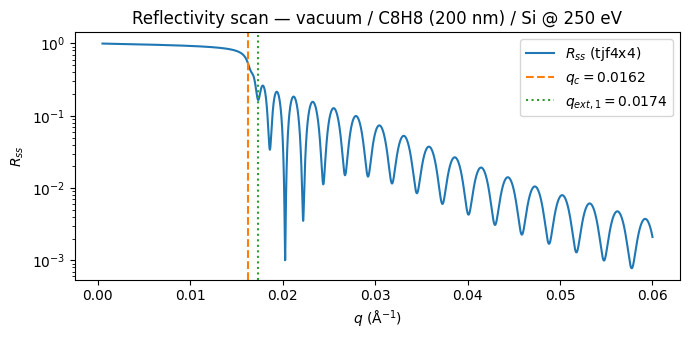

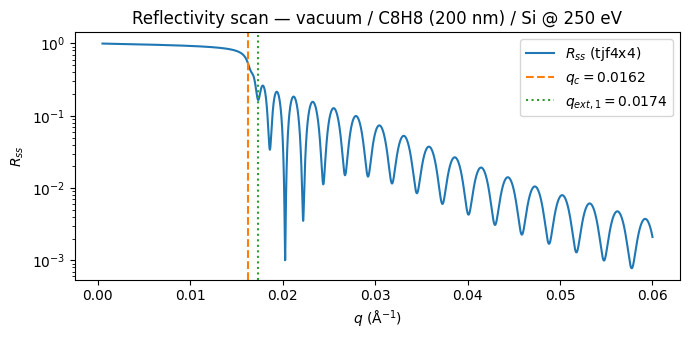

In [3]:
q_scan = np.linspace(0.0005, 0.06, 6000)
refl_tjf, *_ = uniaxial_reflectivity(q_scan, slabs, tensor, ENERGY_EV)
R_ss_tjf = refl_tjf[:, 0, 0]

q_c = critical_q(n_film)
q_ext, r_ext = first_fringe_extinction_q(q_scan, R_ss_tjf, q_c)

idx_c = int(np.argmin(np.abs(q_scan - q_c)))
print(f"q_c = {q_c:.6f} A^-1  (theta = {np.degrees(np.arcsin(q_c / (2 * k0))):.3f} deg from normal)")
print(f"R_ss(q_c) = {R_ss_tjf[idx_c]:.4f}")
print(f"first fringe extinction: q = {q_ext:.6f} A^-1, R_ss = {r_ext:.3e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(q_scan, R_ss_tjf, label=r"$R_{ss}$ (tjf4x4)")
ax.axvline(q_c, color="C1", ls="--", label=rf"$q_c = {q_c:.4f}$")
ax.axvline(q_ext, color="C2", ls=":", label=rf"$q_{{ext,1}} = {q_ext:.4f}$")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
ax.set_ylabel(r"$R_{ss}$")
ax.set_title("Reflectivity scan — vacuum / C8H8 (200 nm) / Si @ 250 eV")
ax.legend(loc="upper right")
fig.tight_layout()
fig

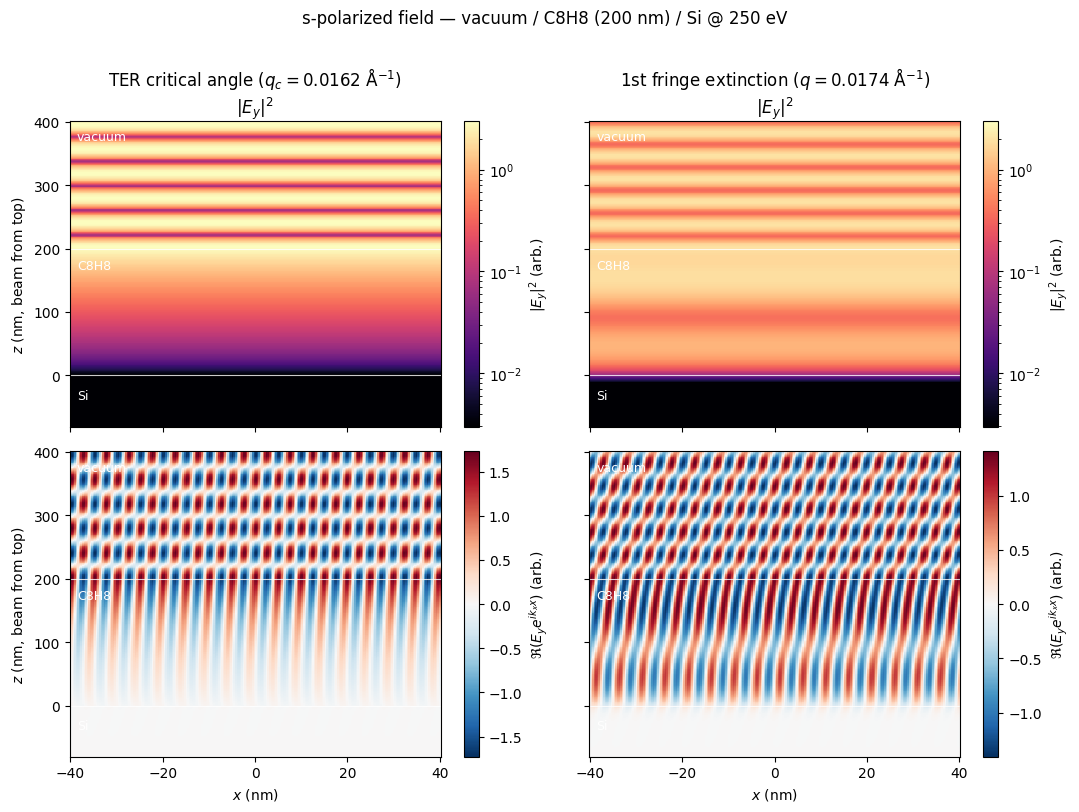

In [5]:
x_nm = np.linspace(-40.0, 40.0, 240)
z_nm = np.linspace(-80.0, 400.0, 360)
x_a = x_nm * 10.0
z_lab_a = z_nm * 10.0

conditions = {
    rf"TER critical angle ($q_c = {q_c:.4f}$ Å$^{{-1}}$)": q_c,
    rf"1st fringe extinction ($q = {q_ext:.4f}$ Å$^{{-1}}$)": q_ext,
}

maps = {
    label: s_field_maps(q_val, x_a, z_lab_a)
    for label, q_val in conditions.items()
}

vmax = max(u.max() for u, _ in maps.values())
fig, axes = plt.subplots(2, 2, figsize=(11, 8.0), sharex=True, sharey=True)

for col, (label, (u, re_e)) in enumerate(maps.items()):
    for row, (data, title_suffix, cmap, norm) in enumerate(
        [
            (u, r"$|E_y|^2$", "magma", LogNorm(vmin=max(vmax * 1e-3, 1e-4), vmax=vmax)),
            (re_e, r"$\Re(E_y e^{ik_x x})$", "RdBu_r", None),
        ]
    ):
        ax = axes[row, col]
        im = ax.pcolormesh(
            x_nm,
            z_nm,
            data,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )
        ax.axhline(0.0, color="w", lw=0.8, alpha=0.8)
        ax.axhline(FILM_NM, color="w", lw=0.8, alpha=0.8)
        ax.text(0.02, 0.97, "vacuum", transform=ax.transAxes, va="top", color="w", fontsize=9)
        ax.text(0.02, 0.55, "C8H8", transform=ax.transAxes, va="top", color="w", fontsize=9)
        ax.text(0.02, 0.08, "Si", transform=ax.transAxes, va="bottom", color="w", fontsize=9)
        if row == 0:
            ax.set_title(f"{label}\n{title_suffix}")
        fig.colorbar(im, ax=ax, label=f"{title_suffix} (arb.)")

axes[0, 0].set_ylabel(r"$z$ (nm, beam from top)")
axes[1, 0].set_ylabel(r"$z$ (nm, beam from top)")
for ax in axes[1, :]:
    ax.set_xlabel(r"$x$ (nm)")

fig.suptitle(
    "s-polarized field — vacuum / C8H8 (200 nm) / Si @ 250 eV",
    y=1.01,
)
fig.tight_layout()
plt.show()